# Allocation Metrics Visualization

In [1]:
from pathlib import Path
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd

SAVE_FIGURES = False
OUTPUT_DIR = Path("plots")

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Đọc và kiểm tra dữ liệu

In [2]:
# FILE_PATH = Path("summary.csv")

# if not FILE_PATH.is_file():
#     raise FileNotFoundError(f"Không tìm thấy file CSV: {FILE_PATH.resolve()}")

# df = pd.read_csv(FILE_PATH)

csv_data = """
mode,valid_events,timestamp_batches,transmitted,suppressed,transmission_ratio,reduction,mae,rmse,p95,p99,max,cvar95,cvar99,bound_violation_count,suppression_violation_count,budget_violation_count,max_bound_utilization,mean_budget_utilization,unused_budget,unused_budget_ratio,number_of_cycles_with_unused_budget,cap_hit_count,cap_hit_rate,redistribution_rounds,within_household_redistributed_budget,cross_household_spill_budget,maximum_consecutive_suppression,house_budget
full_tx,8490773,193653,8490773,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,13.20415702547498,1.0,648,0,0.0,0,0.0,0.0,0,13.20415702547498
uniform,8490773,193653,3832072,4658701,0.4513219232218315,0.5486780767781685,0.10949240910288721,0.1782495355031837,0.3979999999999997,0.5209999999999582,0.9620000000004438,0.4740038191577492,0.5839523195876634,0,0,0,0.07285584366684239,1.0,0.0,0.0,0,0,0.0,0,0.0,0.0,57953,13.20415702547498
flat_variance,8490773,193653,4359736,4131037,0.5134675017221636,0.4865324982778364,0.04789493836914484,0.1946252701271784,0.236000000000422,1.0509999999999946,6.157500000000027,0.7044419084994352,1.4761285493030525,0,0,0,0.466330413075236,1.0,1.7763568394002505e-15,1.345301207773505e-16,0,0,0.0,0,0.0,0.0,57953,13.20415702547498
true_hierarchical,8490773,193653,4229637,4261136,0.4981451041030069,0.5018548958969931,0.05836823596846064,0.18080688549684779,0.242999999999995,0.9460000000000085,4.7120000000002165,0.6458647617082753,1.3355893133711982,0,0,0,0.35685731326197373,1.0,0.0,0.0,0,0,0.0,0,0.0,0.0,57953,13.20415702547498
true_hierarchical_cap,8490773,193653,4229637,4261136,0.4981451041030069,0.5018548958969931,0.05836823596846064,0.18080688549684779,0.242999999999995,0.9460000000000085,4.7120000000002165,0.6458647617082753,1.3355893133711982,0,0,0,0.35685731326197373,1.0,0.0,0.0,0,0,0.0,0,0.0,0.0,57953,13.20415702547498
"""

df = pd.read_csv(StringIO(csv_data))

In [3]:
required_columns = {
    "mode",
    "transmitted",
    "suppressed",
    "transmission_ratio",
    "reduction",
    "mae",
    "rmse",
    "p95",
    "p99",
    "max",
    "cvar95",
    "cvar99",
    "max_bound_utilization",
    "mean_budget_utilization",
    "cap_hit_count",
    "redistribution_rounds",
    "maximum_consecutive_suppression",
}

missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError(
        "File CSV thiếu các cột bắt buộc: " + ", ".join(missing_columns)
    )

df.head()


,mode,valid_events,timestamp_batches,transmitted,suppressed,transmission_ratio,reduction,mae,rmse,p95,...,unused_budget,unused_budget_ratio,number_of_cycles_with_unused_budget,cap_hit_count,cap_hit_rate,redistribution_rounds,within_household_redistributed_budget,cross_household_spill_budget,maximum_consecutive_suppression,house_budget
0,full_tx,8490773,193653,8490773,0,1.000000,0.000000,0.000000,0.000000,0.000,...,1.320416e+01,1.000000e+00,648,0,0.0,0,0.0,0.0,0,13.204157
1,uniform,8490773,193653,3832072,4658701,0.451322,0.548678,0.109492,0.178250,0.398,...,0.000000e+00,0.000000e+00,0,0,0.0,0,0.0,0.0,57953,13.204157
2,flat_variance,8490773,193653,4359736,4131037,0.513468,0.486532,0.047895,0.194625,0.236,...,1.776357e-15,1.345301e-16,0,0,0.0,0,0.0,0.0,57953,13.204157
3,true_hierarchical,8490773,193653,4229637,4261136,0.498145,0.501855,0.058368,0.180807,0.243,...,0.000000e+00,0.000000e+00,0,0,0.0,0,0.0,0.0,57953,13.204157
4,true_hierarchical_cap,8490773,193653,4229637,4261136,0.498145,0.501855,0.058368,0.180807,0.243,...,0.000000e+00,0.000000e+00,0,0,0.0,0,0.0,0.0,57953,13.204157


## Chuẩn hóa tên mode và khai báo hàm hỗ trợ

In [4]:
df = df.set_index("mode")

display_names = {
    "full_tx": "Full TX",
    "uniform": "Uniform",
    "flat_variance": "Flat variance",
    "legacy_two_stage": "Legacy 2-stage",
    "true_hierarchical": "True hierarchical",
    "true_hierarchical_cap": "Hierarchical + cap",
}

df.index = [display_names.get(name, name) for name in df.index]
allocation_df = df.drop(index="Full TX", errors="ignore")


def add_bar_labels(ax, decimals: int = 3) -> None:
    """Ghi giá trị lên đầu mỗi cột."""
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=f"%.{decimals}f",
            padding=3,
            fontsize=8,
            rotation=90,
        )


def finish_plot(fig, filename: str) -> None:
    """Căn chỉnh, tùy chọn lưu ảnh và hiển thị biểu đồ."""
    fig.tight_layout()

    if SAVE_FIGURES:
        output_path = OUTPUT_DIR / filename
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()


df


,valid_events,timestamp_batches,transmitted,suppressed,transmission_ratio,reduction,mae,rmse,p95,p99,...,unused_budget,unused_budget_ratio,number_of_cycles_with_unused_budget,cap_hit_count,cap_hit_rate,redistribution_rounds,within_household_redistributed_budget,cross_household_spill_budget,maximum_consecutive_suppression,house_budget
Full TX,8490773,193653,8490773,0,1.000000,0.000000,0.000000,0.000000,0.000,0.000,...,1.320416e+01,1.000000e+00,648,0,0.0,0,0.0,0.0,0,13.204157
Uniform,8490773,193653,3832072,4658701,0.451322,0.548678,0.109492,0.178250,0.398,0.521,...,0.000000e+00,0.000000e+00,0,0,0.0,0,0.0,0.0,57953,13.204157
Flat variance,8490773,193653,4359736,4131037,0.513468,0.486532,0.047895,0.194625,0.236,1.051,...,1.776357e-15,1.345301e-16,0,0,0.0,0,0.0,0.0,57953,13.204157
True hierarchical,8490773,193653,4229637,4261136,0.498145,0.501855,0.058368,0.180807,0.243,0.946,...,0.000000e+00,0.000000e+00,0,0,0.0,0,0.0,0.0,57953,13.204157
Hierarchical + cap,8490773,193653,4229637,4261136,0.498145,0.501855,0.058368,0.180807,0.243,0.946,...,0.000000e+00,0.000000e+00,0,0,0.0,0,0.0,0.0,57953,13.204157


## 1. Transmitted và suppressed events

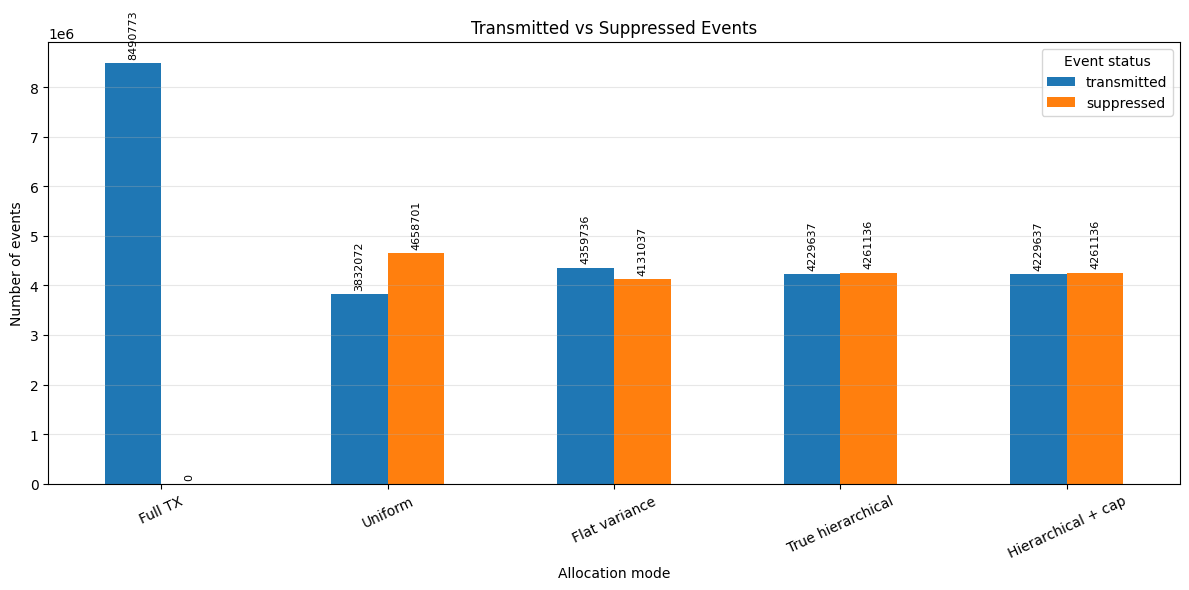

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

df[["transmitted", "suppressed"]].plot(kind="bar", ax=ax)

ax.set_title("Transmitted vs Suppressed Events")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("Number of events")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Event status")

add_bar_labels(ax, decimals=0)
finish_plot(fig, "01_transmitted_vs_suppressed.png")


## 2. Transmission ratio và reduction

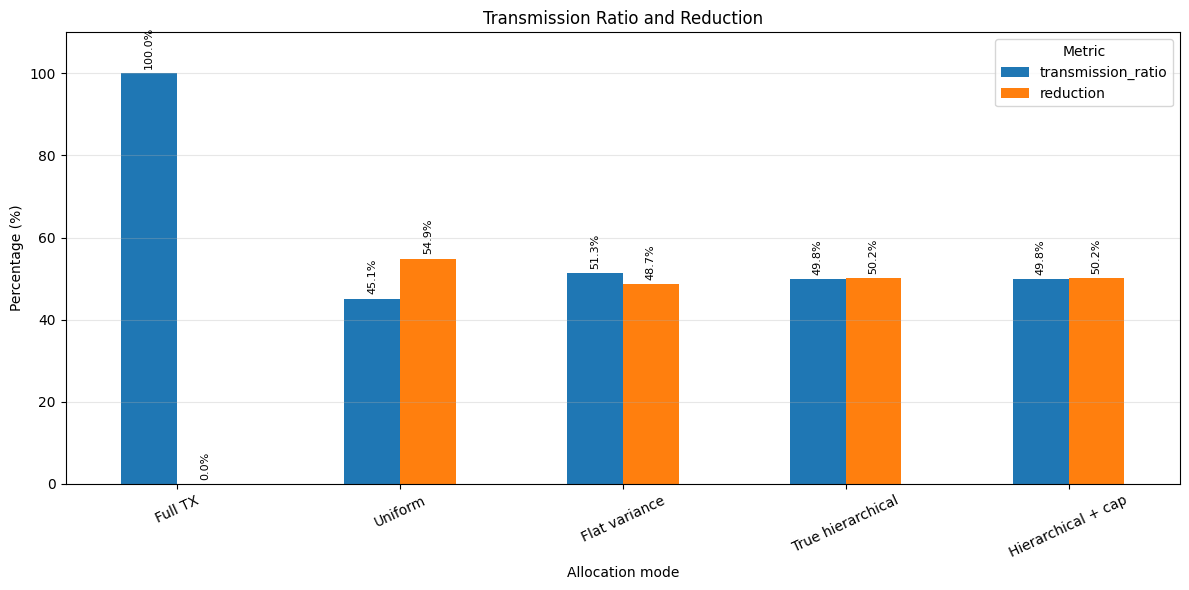

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ratio_df = df[["transmission_ratio", "reduction"]] * 100
ratio_df.plot(kind="bar", ax=ax)

ax.set_title("Transmission Ratio and Reduction")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8,
        rotation=90,
    )

finish_plot(fig, "02_transmission_ratio_and_reduction.png")


## 3. Sai số trung bình: MAE và RMSE

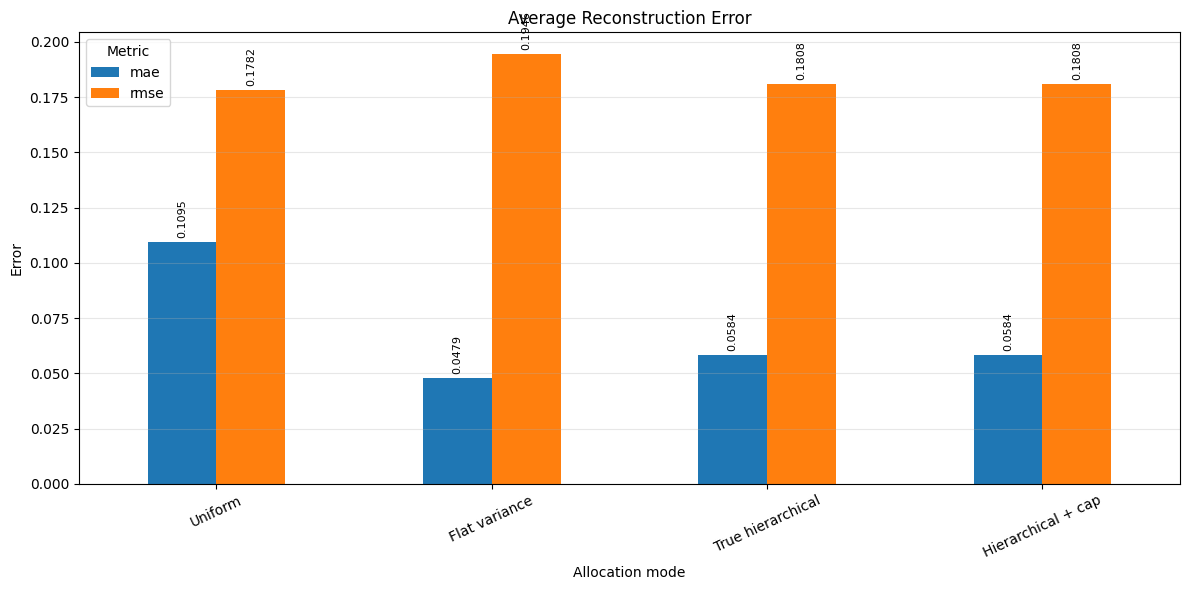

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

allocation_df[["mae", "rmse"]].plot(kind="bar", ax=ax)

ax.set_title("Average Reconstruction Error")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("Error")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

add_bar_labels(ax, decimals=4)
finish_plot(fig, "03_mae_rmse.png")


## 4. Tail error: P95, P99 và maximum

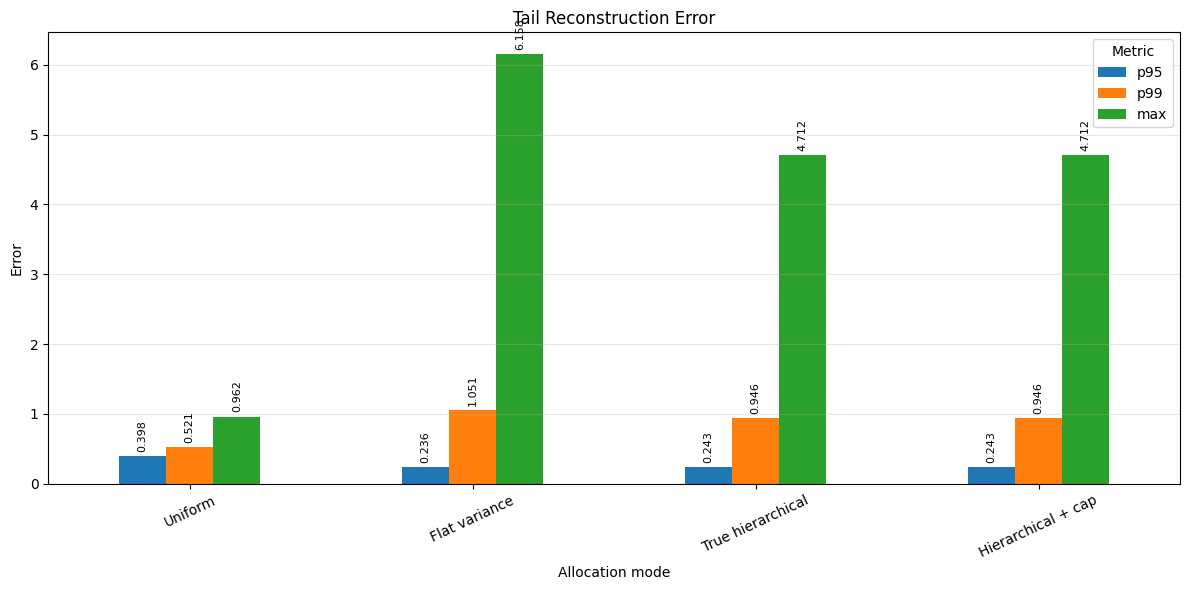

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

allocation_df[["p95", "p99", "max"]].plot(kind="bar", ax=ax)

ax.set_title("Tail Reconstruction Error")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("Error")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

add_bar_labels(ax, decimals=3)
finish_plot(fig, "04_tail_error.png")


## 5. Risk metrics: CVaR95 và CVaR99

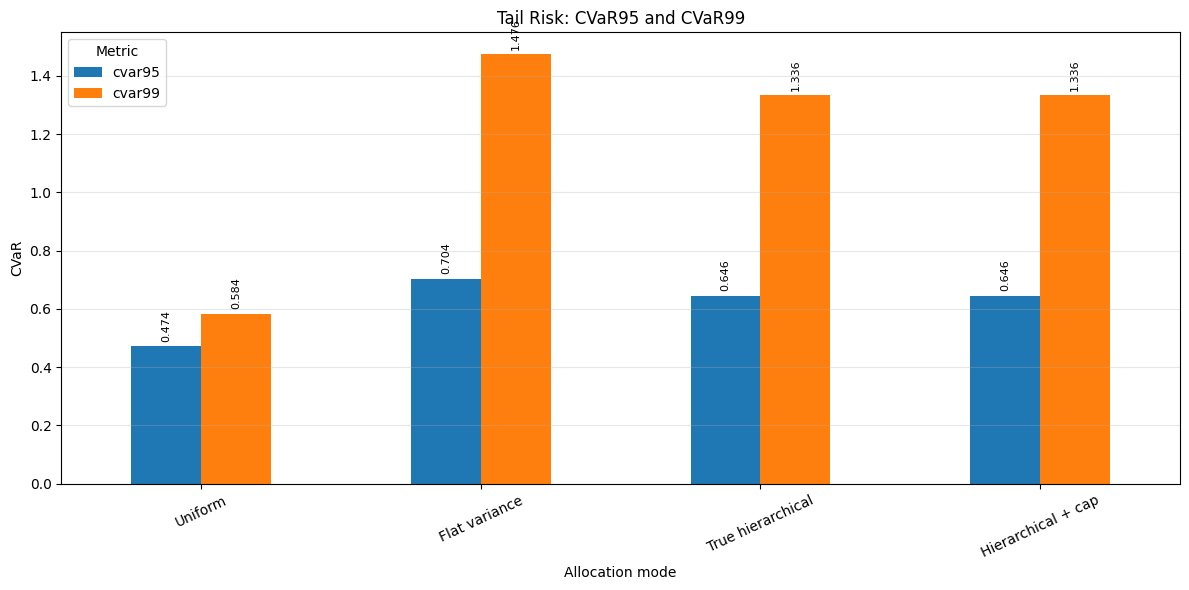

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

allocation_df[["cvar95", "cvar99"]].plot(kind="bar", ax=ax)

ax.set_title("Tail Risk: CVaR95 and CVaR99")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("CVaR")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

add_bar_labels(ax, decimals=3)
finish_plot(fig, "05_cvar.png")


## 6. Budget utilization

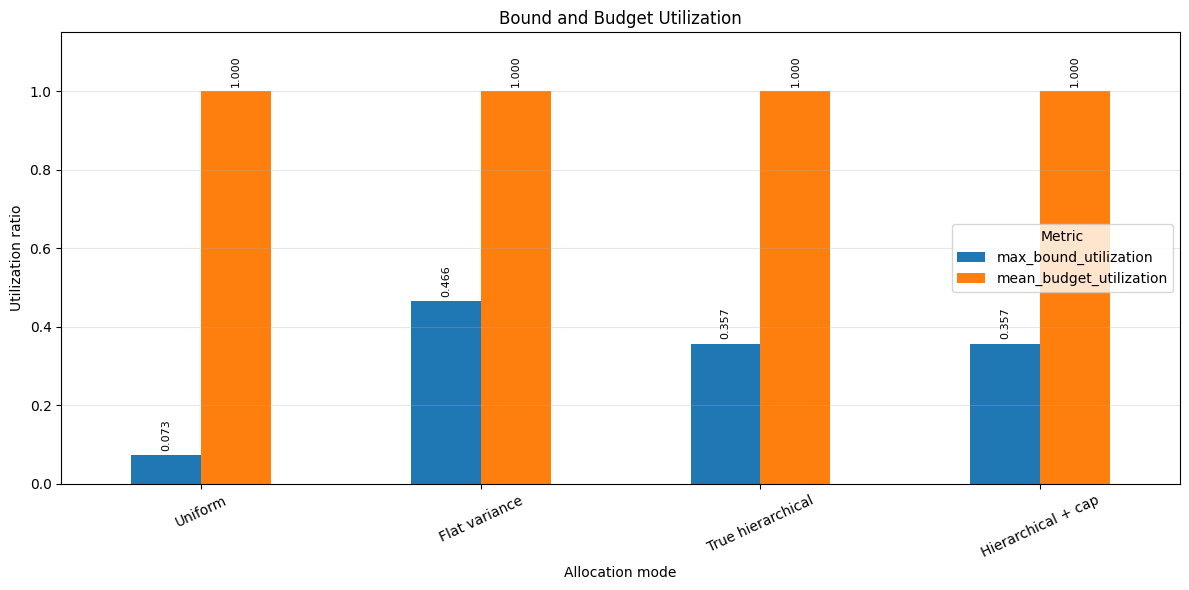

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

allocation_df[
    ["max_bound_utilization", "mean_budget_utilization"]
].plot(kind="bar", ax=ax)

ax.set_title("Bound and Budget Utilization")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("Utilization ratio")
ax.set_ylim(0, 1.15)
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

add_bar_labels(ax, decimals=3)
finish_plot(fig, "06_budget_utilization.png")


## 7. Cap, redistribution và consecutive suppression

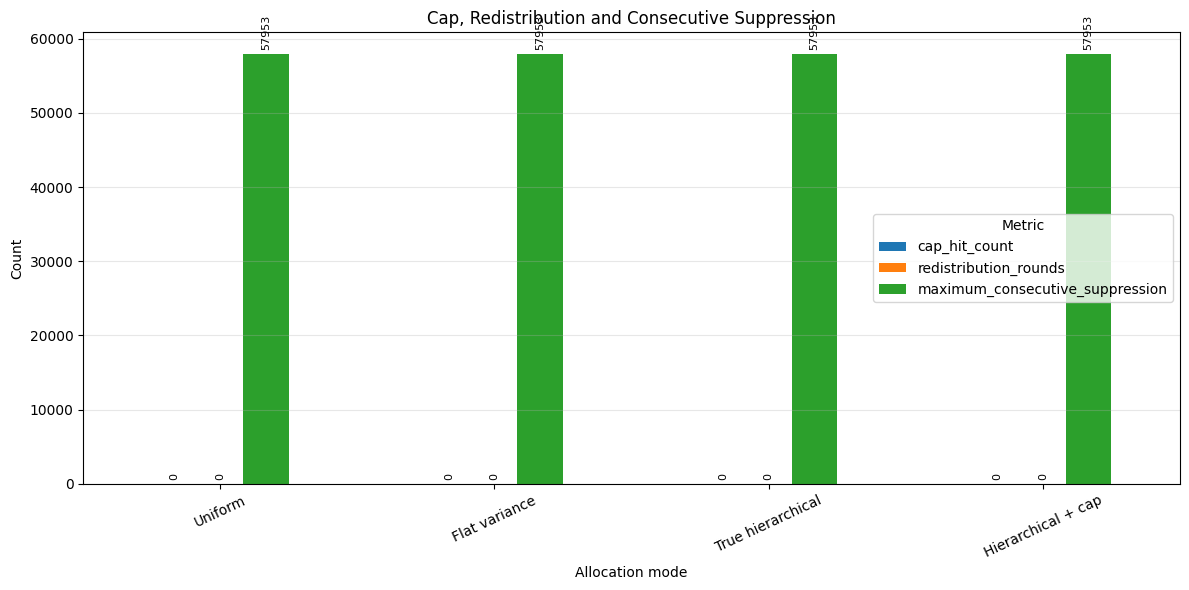

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

allocation_df[
    [
        "cap_hit_count",
        "redistribution_rounds",
        "maximum_consecutive_suppression",
    ]
].plot(kind="bar", ax=ax)

ax.set_title("Cap, Redistribution and Consecutive Suppression")
ax.set_xlabel("Allocation mode")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

add_bar_labels(ax, decimals=0)
finish_plot(fig, "07_cap_and_redistribution.png")
